In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../..").resolve()))

import pandas as pd
from src.utils.db import get_connection

conn = get_connection()

metadata_df = pd.read_sql(
    "SELECT * FROM steam_indie_9692",
    conn
)

details_df = pd.read_sql(
    "SELECT * FROM steam_app_details",
    conn
)

conn.close()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38416\4251600387.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  metadata_df = pd.read_sql(
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_38416\4251600387.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  details_df = pd.read_sql(


In [2]:
metadata_df.dtypes

appid              int64
name                 str
owners               str
positive           int64
negative           int64
price              int64
ccu                int64
genres               str
release_date         str
developers           str
total_reviews        str
owners_lower         str
is_f2p               str
is_early_access      str
dtype: object

In [2]:
# 출시 날짜 datetime형 변환
metadata_df['release_date'] = pd.to_datetime(metadata_df['release_date'])

# 총 리뷰수 정수형 변환
metadata_df['total_reviews'] = metadata_df['total_reviews'].apply(pd.to_numeric, errors = 'coerce')

# 소유자(판매량) 하한선 정수형 변환
metadata_df['owners_lower'] = metadata_df['owners_lower'].apply(pd.to_numeric, errors = 'coerce')

In [3]:
# indie_9692에 steam_app_details 결합
merge_df = pd.merge(metadata_df, details_df, on = 'appid')
merge_df.dtypes

appid                             int64
name_x                              str
owners                              str
positive                          int64
negative                          int64
price                             int64
ccu                               int64
genres_x                            str
release_date_x           datetime64[us]
developers_x                        str
total_reviews                     int64
owners_lower                      int64
is_f2p                              str
is_early_access                     str
name_y                              str
type                                str
is_free                             str
controller_support                  str
short_description                   str
supported_languages                 str
developers_y                        str
publishers                          str
genres_y                            str
categories                          str
coming_soon                         str


In [5]:
# details 붙이기 전 : 9692개, 붙인 후 : 9548개
# details 정보가 없는 게임 144개
merge_df.shape

(9548, 42)

In [4]:
# 중복 컬럼 제거
merge_df = merge_df.drop(columns= ['name_y', 'genres_y', 'release_date_y', 'developers_y', 'type', 'is_free', 'metacritic_url', 'header_image', 'website', 'collected_at'])

# 컬럼명 중복되서 x 붙여졌던 것들 이름 바꾸기
merge_df = merge_df.rename(columns = {"name_x" : "name", "genres_x" : "genres", "release_date_x" : "release_date", "developers_x" : "developers" })

In [5]:
# 무료 게임 여부 부울형 변환
merge_df['is_f2p'] = merge_df['is_f2p'].str.lower().replace({'true' : True, 'false' : False})

# 얼리엑세스 여부 부울형 변환
merge_df['is_early_access'] = merge_df['is_early_access'].str.lower().replace({'true' : True, 'false' : False})

# 출시 전 여부 부울형 변환
merge_df['coming_soon'] = merge_df['coming_soon'].str.lower().replace({'true' : True, 'false' : False})

# 각 OS 지원 여부 부울형 변화
merge_df['windows'] = merge_df['windows'].str.lower().replace({'true' : True, 'false' : False})
merge_df['mac'] = merge_df['mac'].str.lower().replace({'true' : True, 'false' : False})
merge_df['linux'] = merge_df['linux'].str.lower().replace({'true' : True, 'false' : False})

In [6]:
# 총합 추천 수 정수화 및 이상치 ->  0 변환
merge_df['recommendations_total'] = merge_df['recommendations_total'].fillna(0)
merge_df['recommendations_total'] = merge_df['recommendations_total'].apply(pd.to_numeric, errors = 'coerce')

# 메타크리틱 점수 실수화 및 이상치 -> 0 변환
merge_df['metacritic_score'] = merge_df['metacritic_score'].fillna(0)
merge_df['metacritic_score'] = merge_df['metacritic_score'].apply(pd.to_numeric, errors = 'coerce')

# 총 도전과제 수 정수화 및 이상치 -> 0 변환 
merge_df['achievements_total'] = merge_df['achievements_total'].fillna(0)
merge_df['achievements_total'] = merge_df['achievements_total'].apply(pd.to_numeric, errors = 'coerce')

In [9]:
merge_df.dtypes

appid                             int64
name                                str
owners                              str
positive                          int64
negative                          int64
price                             int64
ccu                               int64
genres                              str
release_date             datetime64[us]
developers                          str
total_reviews                     int64
owners_lower                      int64
is_f2p                           object
is_early_access                  object
controller_support                  str
short_description                   str
supported_languages                 str
publishers                          str
categories                          str
coming_soon                      object
currency                            str
initial                             str
final                               str
discount_percent                    str
initial_formatted                   str


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. 분석을 위한 핵심 변수 생성 (이진 변수화)
# - 멀티플레이 여부: 'Multi-player', 'Co-op', 'PvP' 등의 키워드가 포함되었는지 확인
merge_df['has_multiplayer'] = merge_df['categories'].str.contains('Multi-player|Co-op|PvP', case=False, na=False).astype(int)

# - 컨트롤러 지원 여부: 'full' 혹은 'partial' 값이 존재하는지 확인
merge_df['has_controller'] = merge_df['controller_support'].notna().astype(int)

# - 퍼블리셔 존재 여부: publishers 컬럼이 비어있지 않은지 확인
merge_df['has_publisher'] = merge_df['publishers'].notna().astype(int)

# - OS 지원 확장성: Windows 외에 Mac이나 Linux를 지원하는지 여부
merge_df['multi_os_support'] = ((merge_df['mac'] == True) | (merge_df['linux'] == True)).astype(int)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32412\2911254938.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=merge_df, x=feature, y=target, palette='viridis', ci=95)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32412\2911254938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merge_df, x=feature, y=target, palette='viridis', ci=95)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32412\2911254938.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(data=merge_df, x=feature, y=target, palette='viridis', ci=95)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32412\2911254938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

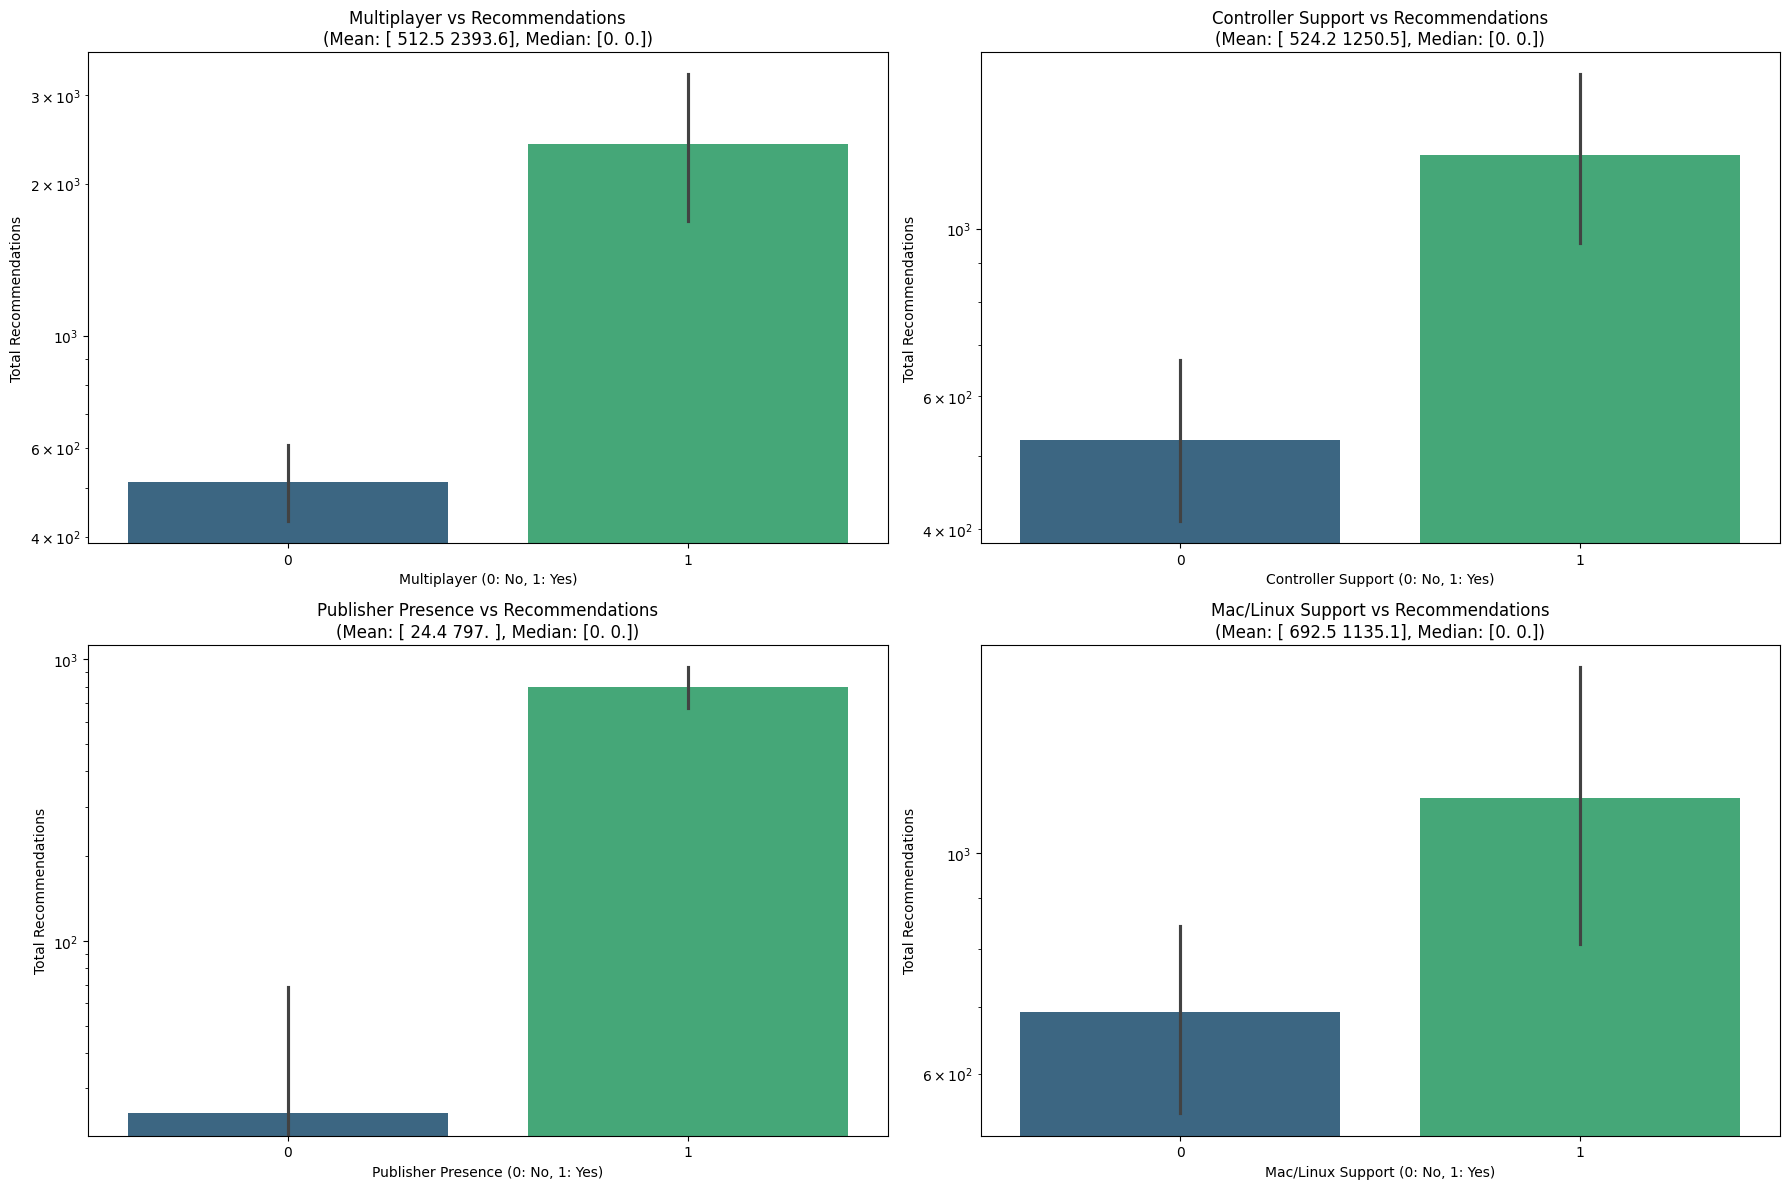

In [13]:
# 분석 대상 지표
target = 'recommendations_total'
features = ['has_multiplayer', 'has_controller', 'has_publisher', 'multi_os_support']
feature_names = ['Multiplayer', 'Controller Support', 'Publisher Presence', 'Mac/Linux Support']

# 2. 그룹별 시각화 (Boxplot & Barplot)
plt.figure(figsize=(18, 12))

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)
    
    # 평균 비교를 위한 Bar plot
    sns.barplot(data=merge_df, x=feature, y=target, palette='viridis', ci=95)
    
    # 중앙값 및 분포 확인을 위한 통계량 계산
    means = merge_df.groupby(feature)[target].mean().round(1)
    medians = merge_df.groupby(feature)[target].median().round(1)
    
    plt.title(f'{feature_names[i]} vs Recommendations\n(Mean: {means.values}, Median: {medians.values})')
    plt.xlabel(f'{feature_names[i]} (0: No, 1: Yes)')
    plt.ylabel('Total Recommendations')
    plt.yscale('log') # 추천 수 편차가 크므로 로그 스케일 적용

plt.tight_layout()
plt.show()

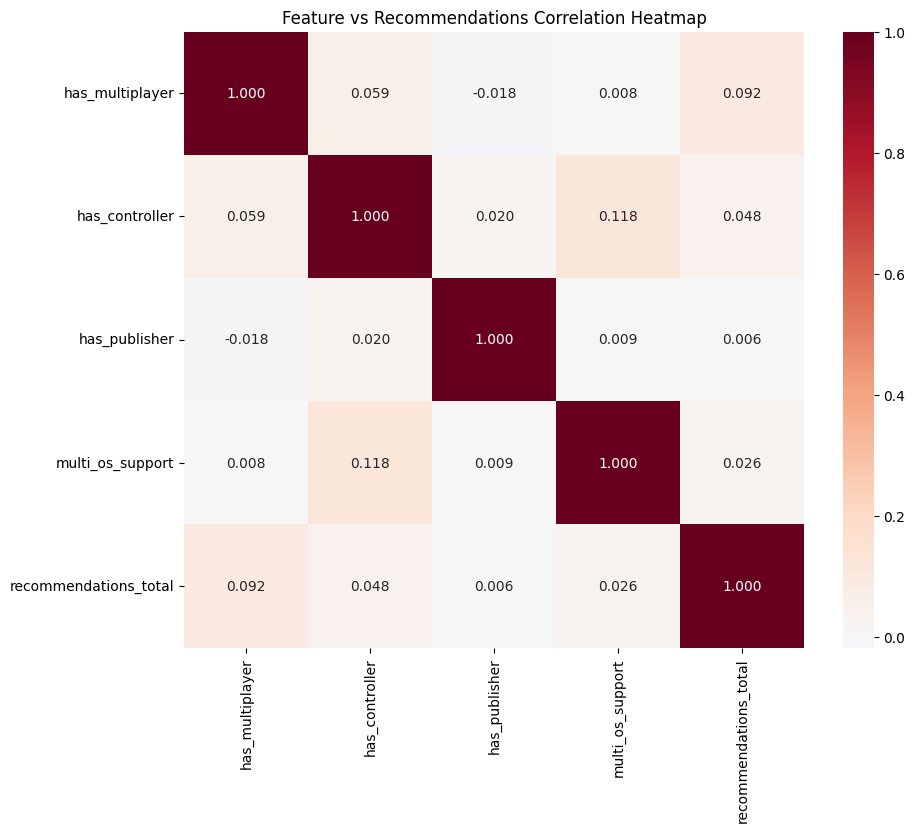

--- [Statistical Significance (T-test)] ---
[Multiplayer] Correlation: 0.0924 | P-value: 8.1055e-06 -> 유의미함(Significant)
[Controller Support] Correlation: 0.0483 | P-value: 5.2859e-05 -> 유의미함(Significant)
[Publisher Presence] Correlation: 0.0059 | P-value: 3.3176e-23 -> 유의미함(Significant)
[Mac/Linux Support] Correlation: 0.0256 | P-value: 2.8197e-02 -> 유의미함(Significant)


In [14]:
# 4. 상관관계 매트릭스 계산 (Point-Biserial Correlation)
corr_matrix = merge_df[features + [target]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".3f", center=0)
plt.title('Feature vs Recommendations Correlation Heatmap')
plt.show()

# 5. 통계적 유의성 검정 (T-test)
print("--- [Statistical Significance (T-test)] ---")
for feature, name in zip(features, feature_names):
    group0 = merge_df[merge_df[feature] == 0][target]
    group1 = merge_df[merge_df[feature] == 1][target]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    
    status = "유의미함(Significant)" if p_val < 0.05 else "유의미하지 않음"
    print(f"[{name}] Correlation: {corr_matrix.loc[feature, target]:.4f} | P-value: {p_val:.4e} -> {status}")

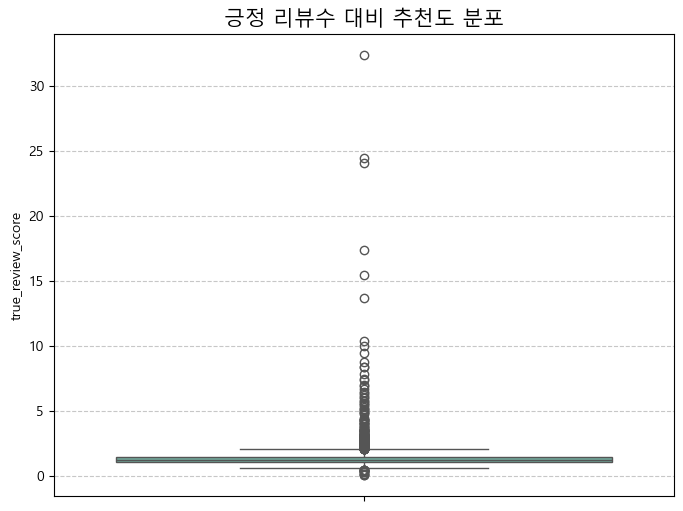

In [26]:
import warnings
warnings.filterwarnings('ignore')

# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

merge_df['true_review_score'] = merge_df['recommendations_total'] / merge_df['positive']

test_df = merge_df.copy()
test_df = test_df[test_df['recommendations_total'] != 0]

# 시각화 설정
plt.figure(figsize=(8, 6))

# 3. Boxplot 그리기
sns.boxplot(y=test_df['true_review_score'], color='#69b3a2')

# 그래프 꾸미기
plt.title('긍정 리뷰수 대비 추천도 분포', fontsize=15)
plt.ylabel('true_review_score')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
merge_df[merge_df['total_reviews'] < merge_df['recommendations_total']][['name', 'total_reviews', 'positive', 'negative', 'recommendations_total']]

,name,total_reviews,positive,negative,recommendations_total
2,CyberCorp,322,266,56,328
3,Sons Of The Forest,253546,222495,31051,268419
8,Ready or Not,236196,210654,25542,248691
9,Hades II,64132,60844,3288,108544
13,Escape the Backrooms,102529,93330,9199,112960
...,...,...,...,...,...
8814,Behind Glass: Aquarium Simulator,338,325,13,372
8815,[Bober Bros] The Hole,501,430,71,704
9331,Escape Memoirs: Safe House,232,214,18,259
9395,Super Puzzled Cat,69,69,0,165


In [24]:
def check_self_published(row):
    dev = str(row['developers']).lower().strip()
    pub = str(row['publishers']).lower().strip()
    
    # 1. 완전 일치 여부
    if dev == pub: return 1
    
    # 2. 포함 관계 확인 (a 가 a Corp에 포함되거나 그 반대)
    suffixes = ['corp', 'inc', 'ltd', 'studios', 'studio', 'games']
    for s in suffixes:
        dev = dev.replace(s, '').strip()
        pub = pub.replace(s, '').strip()
    
    return 1 if (dev in pub or pub in dev) else 0

# 새로운 열 생성
merge_df['is_self_published'] = merge_df.apply(check_self_published, axis=1)

In [25]:
merge_df['is_self_published'].value_counts()

is_self_published
1    7320
0    2228
Name: count, dtype: int64

In [26]:
merge_df[merge_df['is_self_published'] == 0]

,appid,name,owners,positive,negative,price,ccu,genres,release_date,developers,...,discount_percent,initial_formatted,final_formatted,windows,mac,linux,recommendations_total,metacritic_score,achievements_total,is_self_published
3,1326470,Sons Of The Forest,"10,000,000 .. 20,000,000",222495,31051,2999,4450,"['Action', 'Adventure', 'Indie', 'Simulation']",2024-02-22,Endnight Games Ltd,...,0,,$29.99,True,False,False,268419,0,32,0
6,2881650,Content Warning,"5,000,000 .. 10,000,000",137483,7608,799,722,"['Action', 'Adventure', 'Indie']",2024-04-01,"Zorro, Wilnyl, Philip, thePetHen, Skog",...,38,"₩ 8,600","₩ 5,330",True,False,False,67197,0,48,0
10,1260320,Party Animals,"2,000,000 .. 5,000,000",50198,13834,1999,3070,"['Action', 'Casual', 'Indie']",2023-09-20,Recreate Games,...,0,,"₩ 25,900",True,False,False,54614,0,116,0
11,2379780,Balatro,"2,000,000 .. 5,000,000",150524,3042,1499,17123,"['Casual', 'Indie', 'Strategy']",2024-02-20,LocalThunk,...,0,,"₩ 16,500",True,True,False,152600,90,31,0
13,1943950,Escape the Backrooms,"2,000,000 .. 5,000,000",93330,9199,999,1756,"['Action', 'Indie']",2025-10-23,"Fancy Games, Blackbird Interactive",...,0,,"₩ 10,500",True,False,False,112960,0,34,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9499,2660500,Devilish Blind Date,"0 .. 20,000",15,1,599,0,"['Action', 'Adventure', 'Casual', 'Indie', 'St...",2023-11-23,DDE,...,0,,"₩ 6,700",True,False,False,0,0,0,0
9508,2845560,Coffee For Cthulhu,"0 .. 20,000",5,6,174,0,"['Adventure', 'Casual', 'Indie', 'RPG', 'Simul...",2024-04-18,"Josiah Parkhurst, Emily Duff, Jacob Moore, Cle...",...,0,,"₩ 4,500",True,False,False,0,0,0,0
9523,2377780,终极功德模拟器 | Zen Simulator,"0 .. 20,000",21,5,199,0,"['Casual', 'Indie', 'RPG', 'Simulation']",2023-04-27,Archimedes Nicholas Xia,...,30,"₩ 2,300","₩ 1,610",True,False,False,0,0,52,0
9539,1504090,Ascendum,"0 .. 20,000",18,0,1399,0,"['Adventure', 'Casual', 'Indie']",2023-04-12,The Caecus,...,0,,"₩ 15,500",True,False,False,0,0,12,0


In [27]:
merge_df[(merge_df['publishers'] != merge_df['developers']) & (merge_df['supported_languages'].str.contains('Simplified Chinese')) & (merge_df['developers'].str.contains(r'[\u4e00-\u9fff]', na=False)) & (merge_df['is_self_published'] == 0)][['name', 'developers', 'publishers', 'supported_languages']]

,name,developers,publishers,supported_languages
91,Hero's Adventure: Road to Passion,半瓶醋工作室（Half Amateur Studio）,XD,"Simplified Chinese, Traditional Chinese, Engli..."
129,Homicipher,八名木Games,Gamirror Games,"English, Japanese, Simplified Chinese, Traditi..."
162,Ballads of Hongye: REBORN,珠海金山数字网络科技有限公司,"海南西山居互动娱乐科技有限公司, Gamirror Games",Simplified Chinese<strong>*</strong><br><stron...
165,Noobs Want to Live,元气弹工作室(GD Studio),Lightning Games,"Simplified Chinese, English, Traditional Chine..."
312,Chinese Online Game,648工作室,Wise Games,Simplified Chinese<strong>*</strong><br><stron...
...,...,...,...,...
8221,Black Fairy Tale,套鹿工作室,寻鹿计划,"English, Simplified Chinese"
8936,冬眠（hibernation）,玄机子,燃灯堂,"English, Simplified Chinese, Japanese"
9201,Plateman,柠檬弓工作室,East2West Games,"Simplified Chinese, English, Traditional Chinese"
9336,BeatRider,"无限电玩, Combo X Camp",Neverland Entertainment,"Simplified Chinese, English, Japanese, Traditi..."
